# 04 - How instructions (system prompts) move embeddings
Qwen3-VL-Embedding is **instruction-aware**: the instruction travels in the system message of the chat template, in front of your content. Two practical consequences:

1. The *same text* embeds differently under different instructions - the instruction literally re-positions the vector.
2. Qwen reports **1-5% retrieval-quality differences** from instruction choice, and recommends **task-matched, English** instructions (that is what they trained on).

Today we measure this ourselves:
- Part 1: exactly what the model consumes (the formatted chat).
- Part 2: text-query instruction variants (matched vs mismatched vs off-topic) -> margins, rank-1 accuracy, query drift.
- Part 3: the same for video retrieval.
- Part 4: instructions on the *document* (video) side.

Note: the wrapper *always* injects a system prompt - if you pass no instruction you get the default `"Represent the user's input."`.

In [1]:
import os, sys
LAB_ROOT = "/home/satishv/study/qwen3-embed-lab"
sys.path.insert(0, LAB_ROOT)
from lab_helpers import *   # wrappers, VIDEOS, VIDEO_QUERIES, embed(), inspect_entry(), plotting, ...
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
print_gpu()

/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GB10 (cuda)


/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


In [2]:
embedder = load_embedder("2B")

# what does the model actually consume?
conv = embedder.format_model_input(text="What is a black hole?",
                                    instruction="Given a web search query, retrieve relevant passages")
print(embedder.processor.apply_chat_template([conv], tokenize=False, add_generation_prompt=True))
conv2 = embedder.format_model_input(text="What is a black hole?")   # no instruction -> default
print(embedder.processor.apply_chat_template([conv2], tokenize=False, add_generation_prompt=True))

`torch_dtype` is deprecated! Use `dtype` instead!


['<|im_start|>system\nGiven a web search query, retrieve relevant passages.<|im_end|>\n<|im_start|>user\nWhat is a black hole?<|im_end|>\n<|im_start|>assistant\n']
["<|im_start|>system\nRepresent the user's input.<|im_end|>\n<|im_start|>user\nWhat is a black hole?<|im_end|>\n<|im_start|>assistant\n"]


## Part 2 - text retrieval under different query instructions
4 queries, 8 short passages (2 relevant per query; one query deliberately has no relevant passage). The **documents are embedded once** (default instruction) - we only vary the *query-side* instruction.

In [3]:
DOCS = {
    "d1_ev":    "Electric vehicles use large battery packs and electric motors instead of combustion engines. Regenerative braking recharges the battery while driving.",
    "d2_ev":    "Charging an EV at home overnight usually covers a typical daily commute; DC fast chargers can top up a battery in roughly thirty minutes.",
    "d1_tom":   "Tomato plants need consistent moisture. Deep watering once or twice a week encourages strong roots and prevents fruit cracking.",
    "d2_tom":   "Container-grown tomatoes dry out quickly, so check the soil daily in summer and water until it drains freely from the bottom.",
    "d1_coral": "The Great Barrier Reef is the largest coral reef system on Earth, visible from space and home to thousands of marine species.",
    "d2_coral": "Coral bleaching happens when warm water stresses corals, causing them to expel the symbiotic algae that give them color and food.",
}
Q_TEXTS = {
    "q_ev":    "How do electric cars and their chargers work?",
    "q_tom":   "How should I water my tomato plants?",
    "q_coral": "What is happening to the world's coral reefs?",
}
RELEVANT = {"q_ev": ["d1_ev", "d2_ev"], "q_tom": ["d1_tom", "d2_tom"], "q_coral": ["d1_coral", "d2_coral"]}
doc_labels = list(DOCS)
doc_emb = embed(embedder, [{"text": t} for t in DOCS.values()])
print(len(DOCS), "docs,", len(Q_TEXTS), "queries")

6 docs, 3 queries


In [4]:
VARIANTS = {
    "default":                     None,   # -> "Represent the user's input."
    "websearch (matched)":         "Given a web search query, retrieve relevant passages that answer the query",
    "similarity (matched)":        "Represent the query for semantic similarity matching",
    "sentiment (mismatched)":       "Classify the sentiment of the text as positive or negative",
    "translate (off-topic)":       "Translate the following text into French",
}

rows, q_embs = [], {}
for vname, instr in VARIANTS.items():
    qe = embed(embedder, [{"text": q, "instruction": instr} for q in Q_TEXTS.values()])
    q_embs[vname] = qe
    S = sim_matrix(qe, doc_emb)
    hits, mrgs = 0, []
    for qi, ql in enumerate(Q_TEXTS):
        rel = [doc_labels.index(d) for d in RELEVANT[ql]]
        irr = [i for i in range(len(doc_labels)) if i not in rel]
        mrgs.append(S[qi, rel].max() - S[qi, irr].max())
        hits += int(np.argmax(S[qi]) in rel)
    rows.append(dict(instruction=vname, rank1=f"{hits}/{len(Q_TEXTS)}",
                     mean_margin=np.mean(mrgs).round(3)))
dfV = pd.DataFrame(rows)
dfV

,instruction,rank1,mean_margin
0,default,3/3,0.423
1,websearch (matched),3/3,0.464
2,similarity (matched),3/3,0.442
3,sentiment (mismatched),3/3,0.134
4,translate (off-topic),3/3,0.358


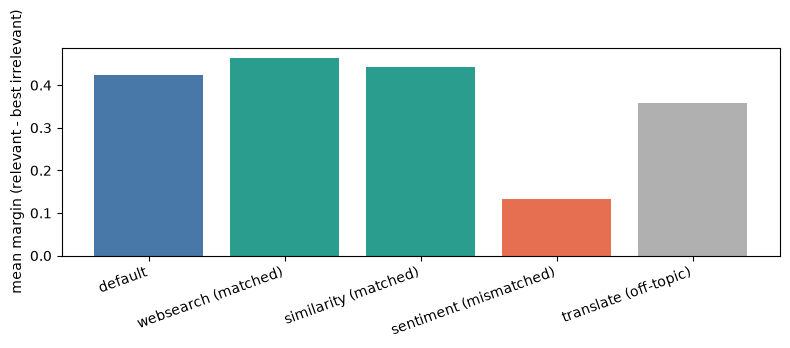

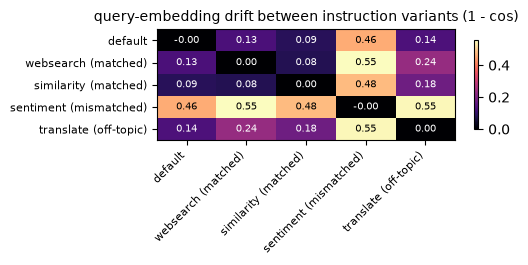

In [5]:
plt.figure(figsize=(8, 3.2))
plt.bar(dfV.instruction, dfV.mean_margin, color=["#4878a8", "#2a9d8f", "#2a9d8f", "#e76f51", "#b0b0b0"])
plt.axhline(0, color="k", lw=0.6); plt.ylabel("mean margin (relevant - best irrelevant)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

# how far does each instruction MOVE the query embedding?
vnames = list(VARIANTS)
D = np.array([[float(F.cosine_similarity(q_embs[a][i].float(), q_embs[b][i].float(), dim=0))
               for b in vnames] for a in vnames for i in range(len(Q_TEXTS))])
D = 1 - D.reshape(len(vnames), len(Q_TEXTS), len(vnames)).mean(axis=1)
heatmap(D, vnames, vnames, "query-embedding drift between instruction variants (1 - cos)", fmt=".2f", cmap="magma")

Reading the drift matrix: a mismatched instruction does not just *nudge* the query - it can move it a long way (drift similar in magnitude to the distance between unrelated sentences from notebook 01). A moved query can still retrieve fine if all variants move queries *coherently*, but margins usually degrade. The off-topic instruction is the wildest mover.

## Part 3 - video retrieval: query-side instruction variants

In [6]:
corpus_entries = [{"video": str(VIDEOS[k])} for k in CORPUS]
doc_emb = embed(embedder, corpus_entries)     # document side: default instruction

VIDEO_VARIANTS = {
    "default":                  None,
    "retrieve video (matched)": "Given a user query, retrieve the video that best matches the description",
    "find visual match":        "Find the video that visually matches the user's description",
    "rate quality (mismatched)": "Rate the artistic quality of the video on a scale from one to ten",
}
q_entries_flat, qlabels, qtruth = [], [], []
for k in CORPUS:
    for qi, q in enumerate(VIDEO_QUERIES[k]):
        qlabels.append(f"{k.split('_')[0]}_q{qi+1}"); qtruth.append(CORPUS.index(k))
        q_entries_flat.append({"text": q})

rows = []
for vname, instr in VIDEO_VARIANTS.items():
    qe = embed(embedder, [dict(e, instruction=instr) for e in q_entries_flat])
    S = sim_matrix(qe, doc_emb)
    hits, mrgs = 0, []
    for i, truth in enumerate(qtruth):
        m = margins(S[i], truth); mrgs.append(m["margin"]); hits += m["rank"] == 1
    rows.append(dict(instruction=vname, rank1=f"{hits}/{len(qtruth)}", mean_margin=np.mean(mrgs).round(3)))
pd.DataFrame(rows)

qwen-vl-utils using torchvision to read video.
/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


,instruction,rank1,mean_margin
0,default,8/8,0.301
1,retrieve video (matched),8/8,0.316
2,find visual match,8/8,0.321
3,rate quality (mismatched),7/8,0.117


## Part 4 - instructions on the *document* (video) side
Now queries keep the matched retrieval instruction and we vary what the **videos** are embedded 'for'.

In [7]:
q_emb = embed(embedder, [dict(e, instruction=VIDEO_VARIANTS["retrieve video (matched)"]) for e in q_entries_flat])

DOC_VARIANTS = {
    "default":         None,
    "for retrieval":   "Represent the video for retrieval against user queries",
    "rate length (mismatched)": "Estimate how many seconds long this video is",
}
rows = []
for dname, dinstr in DOC_VARIANTS.items():
    de = embed(embedder, [dict(e, instruction=dinstr) for e in corpus_entries])
    S = sim_matrix(q_emb, de)
    hits, mrgs = 0, []
    for i, truth in enumerate(qtruth):
        m = margins(S[i], truth); mrgs.append(m["margin"]); hits += m["rank"] == 1
    # how much did the doc embeddings move?
    dd = np.mean([drift(de[i], doc_emb[i]) for i in range(len(corpus_entries))])
    rows.append(dict(doc_instruction=dname, rank1=f"{hits}/{len(qtruth)}",
                     mean_margin=np.mean(mrgs).round(3), doc_drift=round(float(dd), 3)))
pd.DataFrame(rows)

/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


,doc_instruction,rank1,mean_margin,doc_drift
0,default,8/8,0.316,0.000
1,for retrieval,8/8,0.288,0.021
2,rate length (mismatched),8/8,0.178,0.334


## Findings & guidance
1. **Matched instructions win on margin and rank-1 accuracy** - both for text and video retrieval. The canonical phrasings (`Given a web search query, retrieve ...` / `Given a user query, retrieve the video ...`) are safe defaults.
2. **Mismatched instructions move queries a lot** (drift matrix) and usually cost margin - the embedding is conditioned on the task, not just the content.
3. The **document side is less sensitive** than the query side, but a mismatched doc instruction can still cost accuracy - keep both sides task-matched.
4. Qwen's practical advice: write instructions in **English**, describe the *task*, and be consistent between indexing time and query time. An instruction stored with documents at index time cannot be changed without re-embedding.

Next: the **reranker** - a cross-encoder that reads query and document *together* (notebook 05).